# Статьи

* Выбор метрик: https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii

# Выбор метрик для задач классификации

## Загрузка библиотек

In [105]:
import pandas as pd
import numpy as np
import plotly.express as px
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
from sklearn.datasets import load_wine, make_multilabel_classification
from sklearn.multiclass import OneVsRestClassifier
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings('ignore')

## Бинарная классификация

### Загрузка датасета

In [76]:
url = "https://raw.githubusercontent.com/Statology/Python-Guides/main/default.csv"
data = pd.read_csv(url)
X = data[['student', 'balance', 'income']]
y = data['default']

### Тест на сбалансированность

In [83]:
fig = px.histogram(
    data, x="default",
    title='Частота встречаемости классов',
    color=y,
    text_auto=True
)

fig.show()

На графике видно, что у классов сильный дисбаланс, так что в дальнейшем используем SMOTE для уравновешивания классов.

### Стандартизация данных

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pickle.dump(scaler, open("Scaler.sav", 'wb'))

Некоторые алгоритмы классификации чувствительны к масштабу данных => стандартизируем их.

### Разделение на train и test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Уравновешивание классов с помощью SMOTE

In [21]:
smote = SMOTE(sampling_strategy='minority') 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
pickle.dump(smote, open("SMOTE.sav", 'wb'))

In [24]:
Counter(y_train)

Counter({0: 7736, 1: 7736})

SMOTE (Synthetic Minority Over-sampling Technique) — это алгоритм предварительной обработки данных, используемый для устранения дисбаланса классов в наборе данных. 
Он создаёт новые, синтетические примеры, которые помогают модели лучше понять и обобщить характеристики минорных классов.<br>

Устранение дисбаланса классов путем генерации синтетических примеров минорного класса (не изменяет данные, делая их "реальными"). Дисбаланс классов может ухудшить качество модели, особенно для минорного класса.

### Обучение моделей

#### LogisticRegressor

In [25]:
log_reg = LogisticRegression(random_state=42)

param_grid = [
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

gs_log_reg = GridSearchCV(log_reg, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_log_reg = gs_log_reg.fit(X_train, y_train)

print("Best parameters found: ", best_log_reg.best_params_)
print("Best cross-validation score: ", best_log_reg.best_score_)

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits
Best parameters found:  {'C': 0.012742749857031334, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score:  0.8865690975340197


Logistic Regression — это статистический метод бинарной классификации, который предсказывает вероятность принадлежности объекта к одному из двух классов (например, 0 или 1). В отличие от линейной регрессии, логистическая регрессия использует логистическую функцию (сигмоиду) для преобразования линейной комбинации признаков в вероятность в диапазоне [0, 1].

Параметры для подбора:

* penalty (вид регуляризации):

    * l1 (Lasso) - отбор признаков

    * l2 (Ridge) - уменьшение весов

    * elasticnet - комбинация L1+L2

    * none - без регуляризации

* C (сила регуляризации): np.logspace(-4,4,20) (20 значений от 0.0001 до 10000) - контроль переобучения

* solver (алгоритм оптимизации):

    * liblinear - для небольших датасетов

    * lbfgs/newton-cg - для L2 регуляризации

    * sag/saga - для больших датасетов

    * max_iter (макс. итераций): [100,1000,2500,5000] - предотвращение ранней остановки

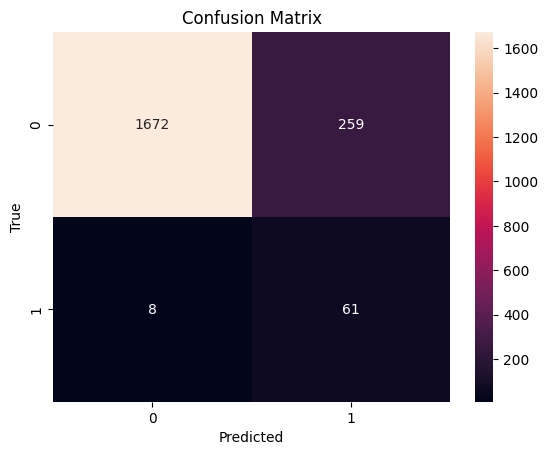

In [26]:
y_pred = best_log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

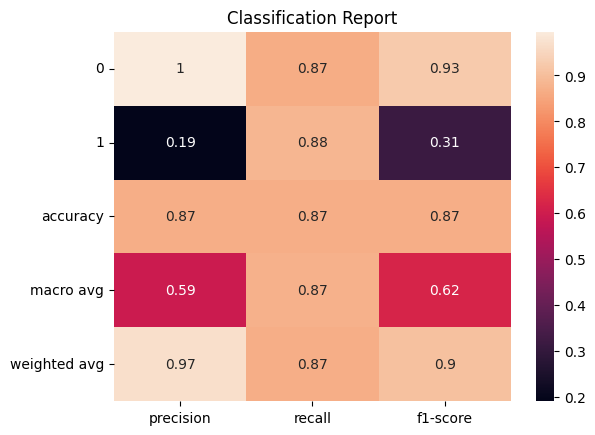

In [27]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### RandomForestClassifier

In [28]:
rfc = RandomForestClassifier(random_state=42)

param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

gs_rfc = GridSearchCV(rfc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_rfc = gs_rfc.fit(X_train, y_train)

print("Best parameters found: ", best_rfc.best_params_)
print("Best cross-validation score: ", best_rfc.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}
Best cross-validation score:  0.9148137396190034


Random Forest — это ансамблевый алгоритм машинного обучения, который строит множество решающих деревьев (Decision Trees) и объединяет их предсказания для повышения точности и устойчивости модели.

Каждое дерево обучается на:

Случайном подмножестве данных (бутстрэп-выборка)

Случайном подмножестве признаков

Итоговый прогноз определяется голосованием (для классификации) или усреднением (для регрессии).

Параметры для подбора:

* n_estimators (количество деревьев): [200, 500] Влияет на стабильность и точность модели

* max_features (число признаков для разделения): ['auto', 'sqrt', 'log2'] - Контроль разнообразия деревьев

* max_depth (максимальная глубина деревьев): [4,5,6,7,8] - Баланс между сложностью и переобучением

* criterion (критерий разделения): ['gini', 'entropy'] - Метод измерения качества разделения

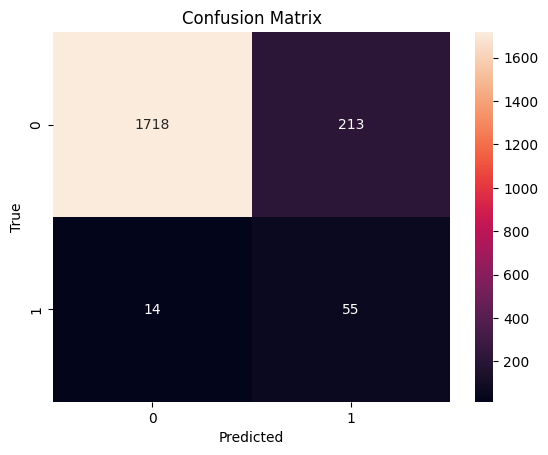

In [29]:
y_pred = best_rfc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

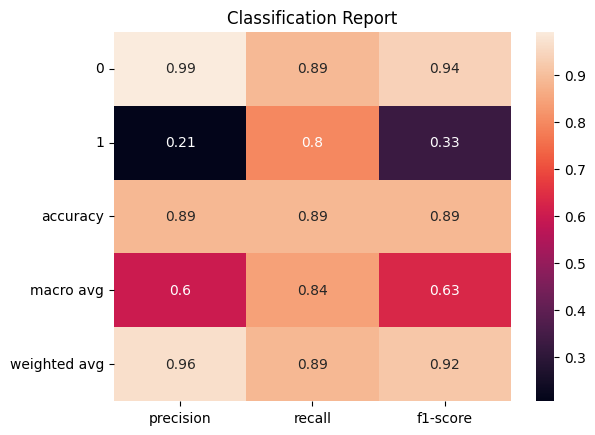

In [30]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### SVC

In [31]:
svc = SVC(random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],  
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
    'kernel': ['rbf']
}

gs_svc = GridSearchCV(svc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_svc = gs_svc.fit(X_train, y_train)

print("Best parameters found: ", best_svc.best_params_)
print("Best cross-validation score: ", best_svc.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters found:  {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score:  0.8949068525787996


Support Vector Classifier (SVC) — это алгоритм машинного обучения для задач классификации, который ищет оптимальную разделяющую гиперплоскость в пространстве признаков, максимизируя зазор (margin) между классами.

Параметры для подбора:
* C (регуляризация): [0.1, 1, 10, 100, 1000] - Баланс между точностью и обобщением

* gamma (влияние точек): [1, 0.1, 0.01, 0.001, 0.0001] - Контроль гладкости границы решения

* kernel (ядро): ['rbf'] - Используется радиальная базисная функция

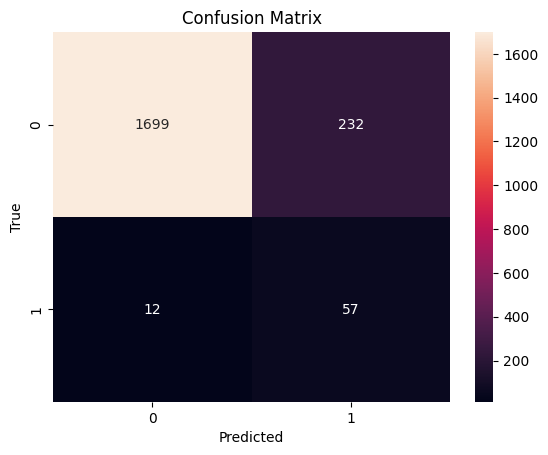

In [32]:
y_pred = best_svc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

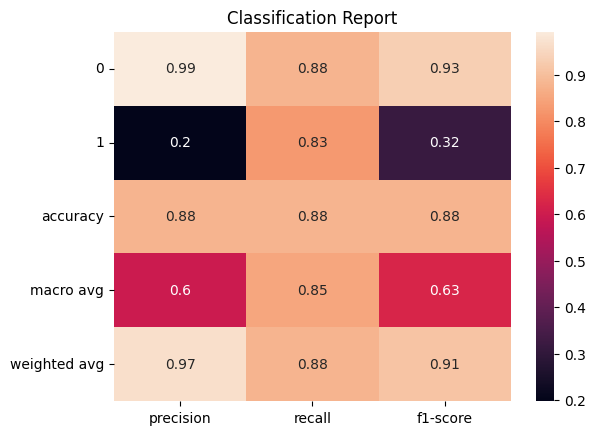

In [33]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

### Вывод
Лучшей моделью оказалась SVC. Её мы и сохраняем. В качестве оценки предпочтение отдавалось weighted f1-score, macro f1-score и confusion matrix.

In [ ]:
pickle.dump(best_svc, open("Classification_Model.sav", 'wb'))

### Уменьшение размерности через PCA

In [36]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(sum(pca.explained_variance_ratio_))

0.9186103256954791


In [ ]:
pickle.dump(pca, open("PCA.sav", 'wb'))

Сжимаем кол-во признаков, чтобы избавиться от мультиколлениарности, упростить модель, уменьшить размерность данных. Для этого оставляем 2 компоненты, так как сохраняется почти 92% вариативности.

### Разделение на train и test

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

### Уравновешивание классов с помощью SMOTE

In [38]:
smote = SMOTE(sampling_strategy='minority') 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
pickle.dump(smote, open("SMOTE.sav", 'wb'))

### Обучение моделей

#### LogisticRegressor

In [39]:
log_reg = LogisticRegression(random_state=42)

param_grid = [
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

gs_log_reg = GridSearchCV(log_reg, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_log_reg = gs_log_reg.fit(X_train, y_train)

print("Best parameters found: ", best_log_reg.best_params_)
print("Best cross-validation score: ", best_log_reg.best_score_)

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits
Best parameters found:  {'C': 0.012742749857031334, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score:  0.8849530205846864


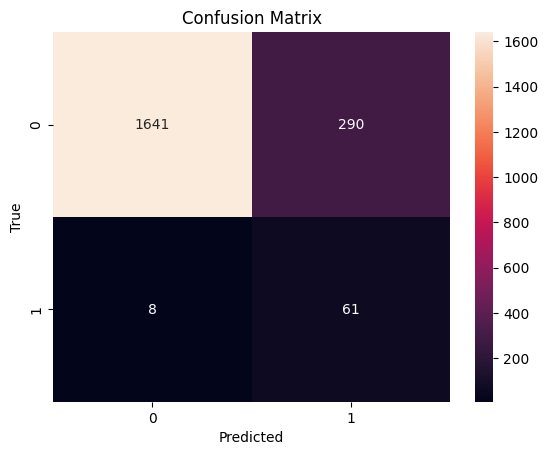

In [40]:
y_pred = best_log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

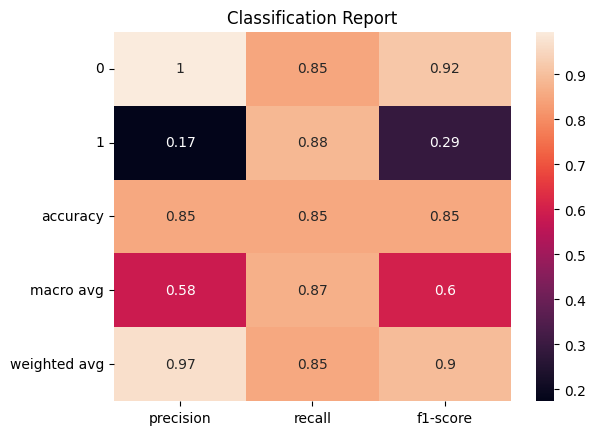

In [41]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### RandomForestClassifier

In [42]:
rfc = RandomForestClassifier(random_state=42)

param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

gs_rfc = GridSearchCV(rfc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_rfc = gs_rfc.fit(X_train, y_train)

print("Best parameters found: ", best_rfc.best_params_)
print("Best cross-validation score: ", best_rfc.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 500}
Best cross-validation score:  0.9201136028335446


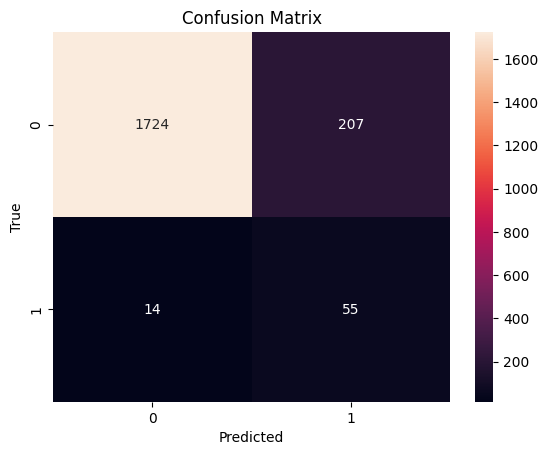

In [43]:
y_pred = best_rfc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

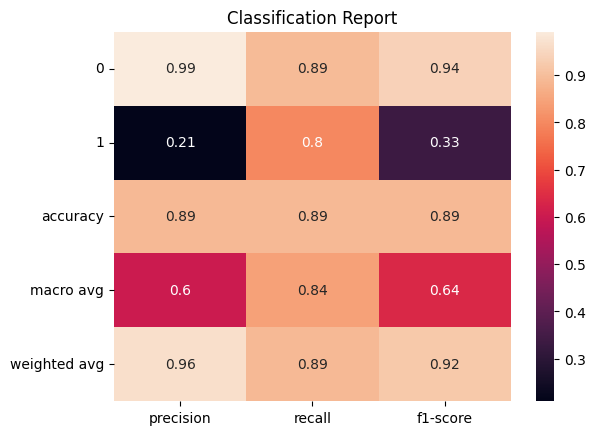

In [44]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### SVC

In [45]:
svc = SVC(random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],  
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
    'kernel': ['rbf']
}

gs_svc = GridSearchCV(svc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_svc = gs_svc.fit(X_train, y_train)

print("Best parameters found: ", best_svc.best_params_)
print("Best cross-validation score: ", best_svc.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters found:  {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score:  0.8928383913777416


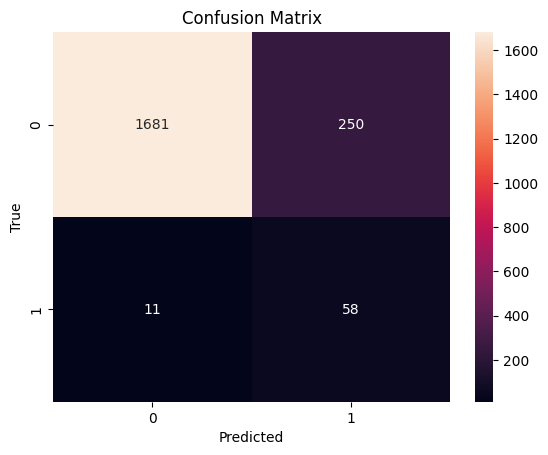

In [46]:
y_pred = best_svc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

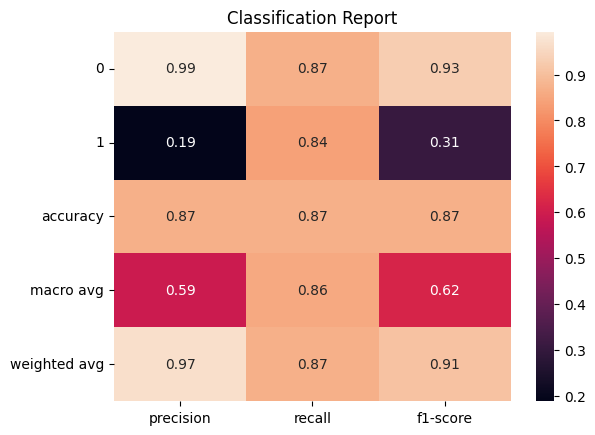

In [47]:
clf_report = classification_report(y_test, y_pred, labels=[0, 1], output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

### Вывод
Лучшей моделью оказалась RandomForestClassifier. Её мы и сохраняем. В качестве оценки предпочтение отдавалось weighted f1-score, macro f1-score и confusion matrix.

In [50]:
pickle.dump(best_rfc, open("Classification_Model.sav", 'wb'))

## Многоклассовая классификация (тоже самое, что и бинарная)

In [85]:
data = load_wine() 
X = data.data 
y = data.target

In [86]:
fig = px.histogram(
    y,
    title='Частота встречаемости классов',
    color=y,
    text_auto=True
)

fig.show()

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
log_reg = LogisticRegression(random_state=42)

param_grid = [
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]
}
]

gs_log_reg = GridSearchCV(log_reg, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_log_reg = gs_log_reg.fit(X_train, y_train)

print("Best parameters found: ", best_log_reg.best_params_)
print("Best cross-validation score: ", best_log_reg.best_score_)

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits
Best parameters found:  {'C': 0.615848211066026, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Best cross-validation score:  0.9507978723404257


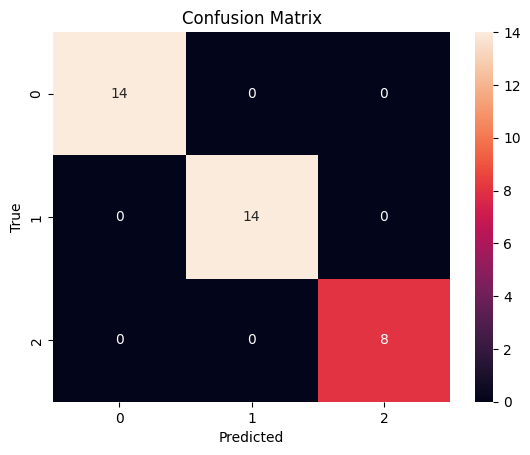

In [ ]:
y_pred = best_log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

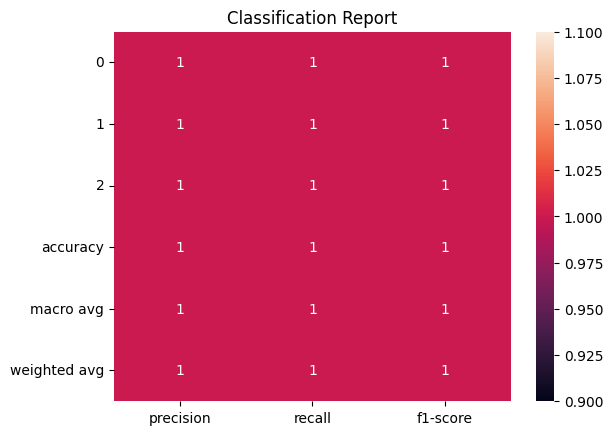

In [66]:
clf_report = classification_report(y_test, y_pred, labels=range(3), output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

## Мультилейбл классификация

In [88]:
# Генерация синтетических данных
X, y = make_multilabel_classification(
    n_samples=1000,       # Число объектов
    n_features=20,        # Число признаков
    n_classes=5,          # Общее число возможных меток
    n_labels=2,           # Среднее число меток на объект
    random_state=42
)

# Преобразование в DataFrame
df_features = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df_labels = pd.DataFrame(y, columns=[f"label_{i}" for i in range(y.shape[1])])

# Объединение в один датасет
data = pd.concat([df_features, df_labels], axis=1)

In [89]:
label_counts = df_labels.sum().sort_values(ascending=False)

# Создаем гистограмму
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    title='Частота встречаемости меток',
    labels={'x': 'Метки', 'y': 'Количество объектов'},
    color=label_counts.index,
    text_auto=True
)

fig.show()

### Стандартизация данных

In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pickle.dump(scaler, open("Scaler.sav", 'wb'))

### Разделение на train и test

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Обучение моделей

#### LogisticRegression

In [96]:
log_reg = OneVsRestClassifier(LogisticRegression(random_state=42))

param_grid = [
    {'estimator__penalty':['l1','l2','elasticnet','none'],
    'estimator__C' : np.logspace(-4,4,20),
    'estimator__solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'estimator__max_iter'  : [100,1000,2500,5000]
}
]

gs_log_reg = GridSearchCV(log_reg, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_log_reg = gs_log_reg.fit(X_train, y_train)

print("Best parameters found: ", best_log_reg.best_params_)
print("Best cross-validation score: ", best_log_reg.best_score_)

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits
Best parameters found:  {'estimator__C': 0.03359818286283781, 'estimator__max_iter': 100, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}
Best cross-validation score:  0.4137872771817183


In [ ]:
y_pred = best_log_reg.predict(X_test)

cm = multilabel_confusion_matrix(y_test, y_pred)


n_classes = cm.shape[0]
fig = make_subplots(rows=1, cols=n_classes, subplot_titles=[f'Класс {i}' for i in range(n_classes)])

for i in range(n_classes):
    fig.add_trace(
        go.Heatmap(
            z=cm[i],
            x=['Не предсказан', 'Предсказан'],
            y=['Не истинный', 'Истинный'],
            colorscale='Blues',
            showscale=False,
            text=cm[i],
            texttemplate="%{text}"
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text='Матрицы ошибок по классам',
    width=400 * n_classes,
    height=500
)

fig.show()

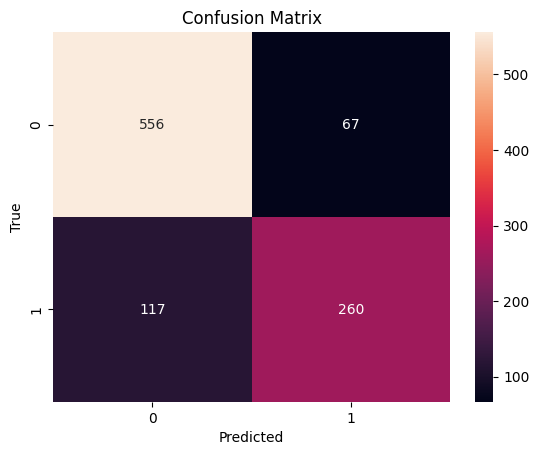

In [107]:
total_cm = cm.sum(axis=0)  # Суммируем по всем классам

sns.heatmap(total_cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

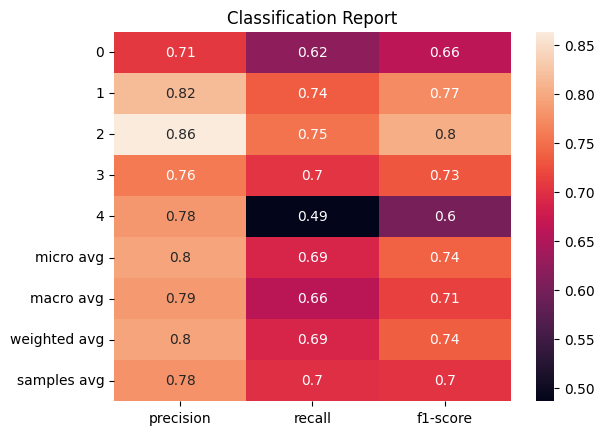

In [108]:
clf_report = classification_report(y_test, y_pred, output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### RandomForestClassifier

In [110]:
rfc = MultiOutputClassifier(RandomForestClassifier(random_state=42))

param_grid = { 
    'estimator__n_estimators': [200, 500],
    'estimator__max_features': ['auto', 'sqrt', 'log2'],
    'estimator__max_depth' : [4,5,6,7,8],
    'estimator__criterion' :['gini', 'entropy']
}

gs_rfc = GridSearchCV(rfc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_rfc = gs_rfc.fit(X_train, y_train)

print("Best parameters found: ", best_rfc.best_params_)
print("Best cross-validation score: ", best_rfc.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found:  {'estimator__criterion': 'entropy', 'estimator__max_depth': 8, 'estimator__max_features': 'sqrt', 'estimator__n_estimators': 500}
Best cross-validation score:  0.4600921780105695


In [111]:
y_pred = best_rfc.predict(X_test)

cm = multilabel_confusion_matrix(y_test, y_pred)


n_classes = cm.shape[0]
fig = make_subplots(rows=1, cols=n_classes, subplot_titles=[f'Класс {i}' for i in range(n_classes)])

for i in range(n_classes):
    fig.add_trace(
        go.Heatmap(
            z=cm[i],
            x=['Не предсказан', 'Предсказан'],
            y=['Не истинный', 'Истинный'],
            colorscale='Blues',
            showscale=False,
            text=cm[i],
            texttemplate="%{text}"
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text='Матрицы ошибок по классам',
    width=400 * n_classes,
    height=500
)

fig.show()

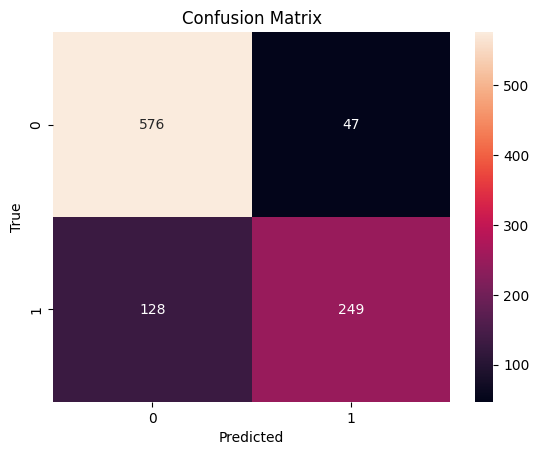

In [112]:
total_cm = cm.sum(axis=0)  # Суммируем по всем классам

sns.heatmap(total_cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

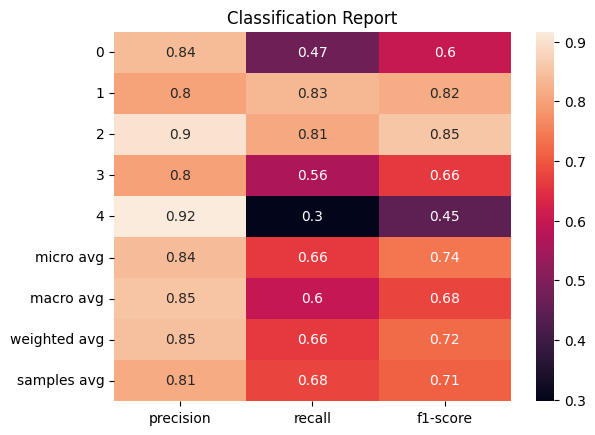

In [113]:
clf_report = classification_report(y_test, y_pred, output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()

#### SVC

In [114]:
svc = MultiOutputClassifier(SVC(random_state=42))

param_grid = {
    'estimator__C': [0.1, 1, 10, 100, 1000],  
    'estimator__gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
    'estimator__kernel': ['rbf']
}

gs_svc = GridSearchCV(svc, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1)

best_svc = gs_svc.fit(X_train, y_train)

print("Best parameters found: ", best_svc.best_params_)
print("Best cross-validation score: ", best_svc.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters found:  {'estimator__C': 10, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}
Best cross-validation score:  0.4750171308420865


In [115]:
y_pred = best_svc.predict(X_test)

cm = multilabel_confusion_matrix(y_test, y_pred)


n_classes = cm.shape[0]
fig = make_subplots(rows=1, cols=n_classes, subplot_titles=[f'Класс {i}' for i in range(n_classes)])

for i in range(n_classes):
    fig.add_trace(
        go.Heatmap(
            z=cm[i],
            x=['Не предсказан', 'Предсказан'],
            y=['Не истинный', 'Истинный'],
            colorscale='Blues',
            showscale=False,
            text=cm[i],
            texttemplate="%{text}"
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text='Матрицы ошибок по классам',
    width=400 * n_classes,
    height=500
)

fig.show()

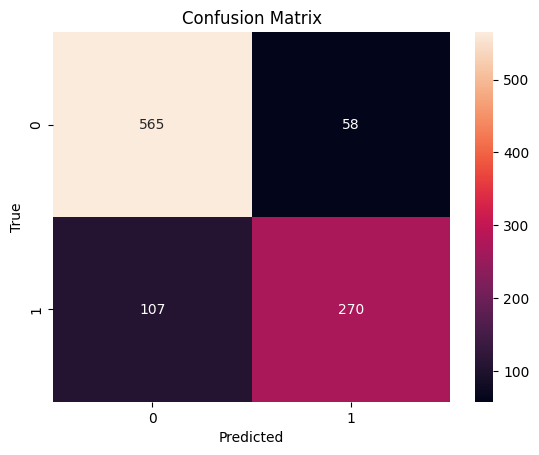

In [116]:
total_cm = cm.sum(axis=0)  # Суммируем по всем классам

sns.heatmap(total_cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

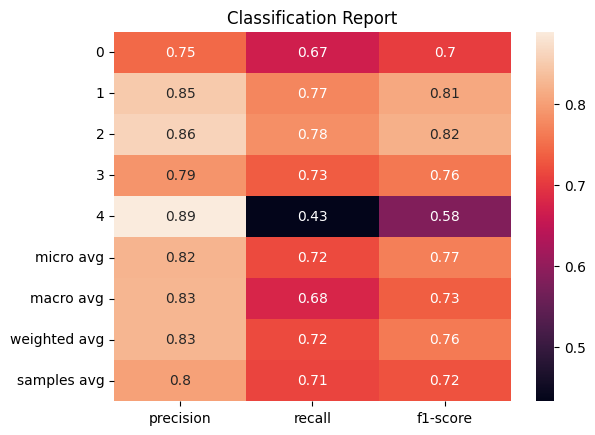

In [117]:
clf_report = classification_report(y_test, y_pred, output_dict=True)
heatmap_plot = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report")
plt.show()